# Lab08：根因分析，以及一張成績單能不能相信

前面五節把 telemetry 變成 alert。Lab03 用 SPC 判斷單一序列有沒有離開穩定狀態，Lab04 換成多變量
geometry，Lab05 決定哪些 alert 值得叫醒人。這五節共用一個前提，就是偵測到異常之後，剩下的事情
交給值班工程師。

這一節處理剩下的事情。系統告訴你 port-id7429 有問題，工程師接著要回答三件事：哪一個 counter
在動、影響範圍到哪裡、這件事是不是我們自己排定的作業。前面每一節都量過 detection 與 delay，
沒有一節量過根因。課程主軸列了根因分析，而它到目前為止是唯一沒有被評分的環節。

這一節也回頭檢查前面的成績單。十個事件、十八個 window，這樣的樣本數能撐起多大的結論，Lab03 到
Lab05 都沒有算過。第 6 到第 9 節就是在算這件事，答案會讓第 5 節那張漂亮的成績單看起來不太一樣。

輸入是 `data/synthetic/` 底下的三個檔案，程式收在 `lib/features.py`、`lib/detect.py`、
`lib/evaluate.py` 與 `lib/rca.py`。載入與畫圖前面幾節已經教過，這一節的格子留給根因。

In [1]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lib.lib import set_figure_style, C, PORT_C, heatmap
from lib.features import (load_telemetry, load_catalog, load_calendar, engineer_features,
                          calendar_mask, counterfactual_normal, attenuate_events,
                          FEATURES, RAW_COLUMNS, FAULT_SIGNATURE, CADENCE_S)
from lib.detect import fit_fleet, score_fleet, DETECTORS
from lib import evaluate as ev
from lib import rca

set_figure_style()
warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 30)

telemetry, contract = load_telemetry()
catalog = load_catalog()
calendar = load_calendar()
print(contract.describe())

rows            43,200 across 5 ports
span            2026-02-01 00:00:00  ->  2026-03-02 23:55:00
cadence         300 s (5 min, 288 samples/day)
column reading  per-interval totals, already differenced
monotonic frac  0.503 of consecutive INOCTETS steps are non-negative
missing cells   0
duplicate rows  0
note            rates come from dividing by the cadence, not from a diff
note            INNUCASTPKTS is smaller than broadcast+multicast on some rows
note            286 rows carry an incident label (0.662% prevalence)


## 1. 資料契約：先確認這份檔案是什麼

`monotonic frac 0.503` 這一行值得停一下。SNMP 的 octet counter 只會往上累加，中間只有 wrap
會往回跳，所以一份真的 counter 匯出，相鄰兩筆的差應該有九成九以上非負。這份檔案是一半。

結論是這些欄位已經是每個區間的量，不是累計值。把它再差分一次會得到雜訊，而這種錯誤不會拋
例外，只會讓後面每一個 baseline 都建在錯的量上。契約要用量的，不是用寫的。

下面兩張表是建模之前唯一要看的東西。第一張問每個 counter 能不能當累計值讀，第二張問每個
feature 有沒有足夠的散布，讓偏離分數有意義。

In [2]:
frame = engineer_features(telemetry)
header, counters, quality = ev.data_quality_report(frame, RAW_COLUMNS, FEATURES)
print(header)
display(counters)
display(quality.round(4))

{'rows': 43200, 'ports': 5, 'missing_cells': 0, 'duplicate_port_time': 0}


,counter,negative_step_frac,zero_frac
0,INOCTETS,0.497,0.000
1,OUTOCTETS,0.498,0.000
2,INERRORS,0.015,0.985
3,OUTERRORS,0.010,0.990
4,INUCASTPKTS,0.497,0.000
5,OUTUCASTPKTS,0.498,0.000
6,INNUCASTPKTS,0.485,0.000
7,OUTNUCASTPKTS,0.483,0.000
8,INDISCARDS,0.038,0.959
9,OUTDISCARDS,0.048,0.948


,feature,zero_frac,mad,cv
0,in_bps,0.000,171291.8105,0.979
1,out_bps,0.000,134033.0479,1.171
2,in_pps,0.000,23.3067,0.980
3,out_pps,0.000,18.7100,1.105
4,avg_pkt_bytes,0.000,123.5630,0.197
5,broadcast_ratio,0.000,0.0002,0.504
6,multicast_ratio,0.000,0.0009,0.750
7,error_rate,0.976,0.0000,29.719
8,discard_rate,0.913,0.0000,15.356
9,unknown_proto_pps,0.990,0.0000,59.900


In [3]:
is_event = frame["event_label"].ne("normal").to_numpy()
planned = calendar_mask(frame, calendar)
display(ev.degenerate_features(frame, FEATURES, mask=~is_event))

,feature,reason,mad,zero_frac
0,error_rate,MAD is zero; zero on 98% of rows,0.0,0.976
1,discard_rate,MAD is zero; zero on 92% of rows,0.0,0.916
2,unknown_proto_pps,MAD is zero; zero on 99% of rows,0.0,0.990


### 三個沒有尺的 feature

`error_rate`、`discard_rate` 與 `unknown_proto_pps` 在正常流量下的 MAD 是 0。九成以上的樣本
是零，中位數是零，絕對離差的中位數也是零，於是 robust z-score 的分母消失。

這三個欄位剛好是十種事件裡四種的 signature，包括 queue congestion、兩種線路品質問題與 unknown
protocol scan。把它們當成髒資料丟掉，那四種事件就永遠歸因不出來。`lib/detect.py` 的作法是 MAD
為零時退回標準差，並且把退回的名單記在 model 上，讓它出現在輸出裡而不是留在程式碼裡。

零膨脹的欄位用標準差當尺並不漂亮，這裡可以接受的理由是它只需要分辨零與非零。真正乾淨的作法是
給這類欄位一條 presence rule，任何非零都算異常，第 12 節的歸因結果會說明為什麼退回標準差在這份
資料上已經夠用。

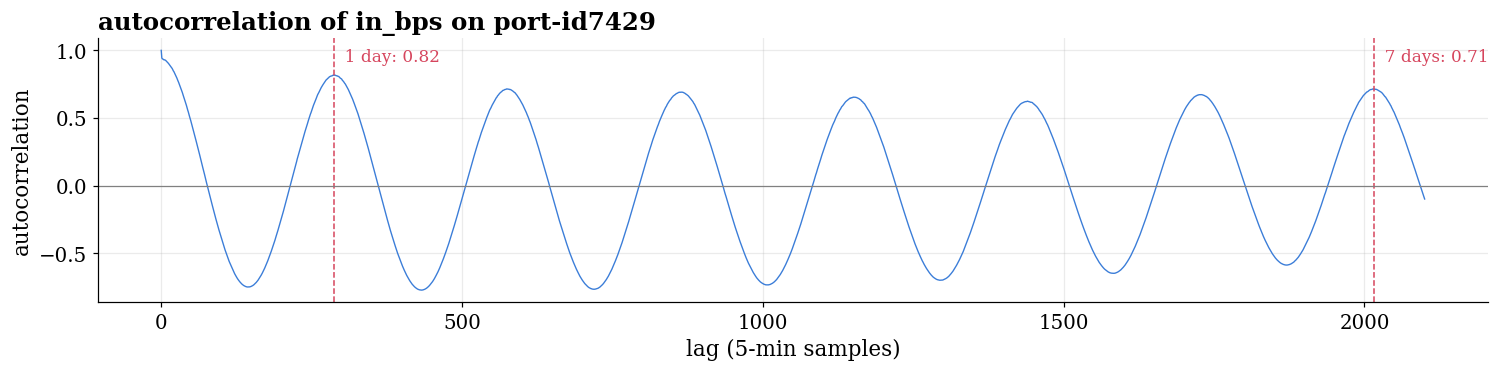

,lag,ljung_box_q,p_value
0,12,88809.3,0.0
1,288,836326.8,0.0
2,2016,4953388.5,0.0


In [4]:
port = "port-id7429"
one = frame[frame["port_id"] == port]
acf = ev.acf_values(one["in_bps"].to_numpy(), nlags=2100)

fig, ax = plt.subplots(figsize=(14, 3.6))
ax.plot(acf, lw=0.9, color=C["signal"])
for lag, label in ((288, "1 day"), (2016, "7 days")):
    ax.axvline(lag, color=C["alert"], ls="--", lw=1.0)
    ax.text(lag, 0.92, f"  {label}: {acf[lag]:.2f}", color=C["alert"], fontsize=11)
ax.axhline(0, color="0.5", lw=0.8)
ax.set(xlabel="lag (5-min samples)", ylabel="autocorrelation",
       title=f"autocorrelation of in_bps on {port}")
plt.show()

display(ev.ljung_box(one["in_bps"].to_numpy(), lags=(12, 288, 2016)))

## 2. Seasonality 決定 baseline 的鍵

一天的自相關 0.82，一週 0.71，兩個週期都在。這座 fleet 平日的平均流量大約 21 Mbit/s，週末大約
12 Mbit/s，只用 hour of day 當 baseline 的鍵，週六下午會被拿去跟平日下午比，讀出來是永久性的
四成下降。

所以 profile 的鍵是 hour of week，168 個 bucket，每個 bucket 取正常樣本的中位數。Lab03 在單一
序列上做過同一件事，這裡的差別只是鍵多了一個星期幾。

Ljung-Box 的 Q 大到 p 值直接是 0。這件事在第 8 節會再用到一次：既然序列有這麼強的記憶，任何
把樣本當成獨立試驗來計算的 alert 量都會低估。

In [5]:
FIT_END = pd.Timestamp("2026-02-15")
CAL_END = pd.Timestamp("2026-02-19")
TARGET_ONSETS_PER_DAY = 0.5          # 與 Lab04 的 false-signal budget 同一個數字

fit_mask = (frame["timestamp"] < FIT_END).to_numpy() & ~is_event & ~planned
cal_mask = ((frame["timestamp"] >= FIT_END)
            & (frame["timestamp"] < CAL_END)).to_numpy() & ~is_event & ~planned
test_mask = (frame["timestamp"] >= CAL_END).to_numpy()

models = fit_fleet(frame, fit_mask)
scores = score_fleet(frame, models)
thresholds = ev.calibrate_fleet(frame, scores, cal_mask, TARGET_ONSETS_PER_DAY,
                                cadence_s=CADENCE_S)
flags = ev.flag_fleet(frame, scores, thresholds)
windows = ev.event_windows(frame)

print(f"fit       {fit_mask.sum():6d} rows   calibrate {cal_mask.sum():6d} rows   "
      f"test {test_mask.sum():6d} rows")
print(f"windows   {len(windows)}  over {windows['event_id'].nunique()} incidents "
      f"and {windows['port_id'].nunique()} ports")
print(f"PCA components kept per port: "
      f"{ {p[-4:]: m.k_ for p, m in models.items()} }")
print(f"MAD fallback: {models[port].mad_fallback_}")

fit        20059 rows   calibrate   5692 rows   test  17280 rows
windows   18  over 10 incidents and 5 ports
PCA components kept per port: {'7427': 7, '7428': 7, '7429': 7, '7430': 7, '7431': 7}
MAD fallback: ['error_rate', 'discard_rate', 'unknown_proto_pps']


## 3. 三段切分，以及切分本身的假設

fit 段估 profile、尺與模型，calibrate 段訂門檻，test 段留著給第 9 節。fit 段先把有標記的事件
視窗與變更視窗拿掉，這是 Phase I 的標準作法，已知的 assignable cause 要先移出參考期。

這一步有代價，要拿掉已知事件就得先有事件紀錄。真實環境裡那份紀錄通常不完整，於是參考期會混進
沒被記錄的事件，模型把它學成正常。第 7 節就是量這件事會有多貴。

門檻用 false-onset budget 訂，一個 port 一天 0.5 次，跟 Lab04 同一個數字。每個 port 各自校準，
因為五個 port 的角色差得太多，共用一條門檻等於把預算全花在最忙的那一個上。

In [6]:
card = ev.event_scorecard(frame, flags, windows, cadence_s=CADENCE_S)
display(card)

,detector,windows_caught,windows,event_recall,median_delay_min,false_onsets_per_port_day
0,IsolationForest,18,18,1.000,0.0,0.60
1,LOF,18,18,1.000,0.0,0.78
2,Max |z|,18,18,1.000,0.0,0.80
3,PCA T2,18,18,1.000,0.0,0.88
4,Mahalanobis,18,18,1.000,0.0,0.91
5,PCA SPE,18,18,1.000,0.0,1.18
6,Robust Mahalanobis,16,18,0.889,0.0,0.99


## 4. 一張沒有資訊的成績單

七個 detector 裡六個 recall 是 1.000，delay 全部是 0 分鐘。這不是六個方法都很好，是這個問題太
簡單：季節性拿掉、每個 port 各自標準化之後，最弱的事件也離正常中位數三十倍以上。

一張所有人都滿分的成績單無法排序方法，也無法告訴你換方法會得到什麼。要讓它有資訊，得先讓題目
變難。

In [7]:
counterfactual = counterfactual_normal(telemetry)
STRENGTHS = (1.0, 0.5, 0.3, 0.2, 0.15, 0.1, 0.05, 0.03, 0.02, 0.01)

def sweep(models, thresholds, strengths=STRENGTHS):
    # 模型與門檻固定，只把事件本身調弱。變動的只有事件強度這一個量。
    rows = []
    for s in strengths:
        weak = engineer_features(attenuate_events(telemetry, counterfactual, s))
        weak_flags = ev.flag_fleet(weak, score_fleet(weak, models), thresholds)
        got = ev.event_scorecard(weak, weak_flags, windows,
                                 cadence_s=CADENCE_S).set_index("detector")
        rows.append(pd.Series(got["event_recall"], name=s))
    out = pd.DataFrame(rows)
    out.index.name = "strength"
    return out[list(DETECTORS)]

recall_by_strength = sweep(models, thresholds)
display(recall_by_strength)

def detection_floor(table, level=0.8):
    # 撐得住 recall >= level 的最低事件強度。數字越小越靈敏。
    return pd.Series({c: min([i for i in table.index if table.loc[i, c] >= level],
                             default=np.nan) for c in table.columns},
                     name=f"floor at recall {level}")

floors = detection_floor(recall_by_strength)
display(floors.to_frame().T)

detector,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest
strength,,,,,,,
1.00,1.000,1.000,0.889,1.000,1.000,1.000,1.000
0.50,1.000,1.000,0.778,1.000,1.000,1.000,0.722
0.30,1.000,1.000,0.722,1.000,0.944,1.000,0.722
0.20,1.000,1.000,0.722,1.000,0.889,1.000,0.667
0.15,1.000,1.000,0.722,1.000,0.833,1.000,0.556
0.10,1.000,1.000,0.667,1.000,0.722,1.000,0.333
0.05,0.889,0.889,0.611,0.889,0.444,0.944,0.111
0.03,0.889,0.778,0.500,0.833,0.222,0.889,0.056
0.02,0.833,0.667,0.222,0.667,0.111,0.778,0.056


,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest
floor at recall 0.8,0.02,0.05,1.0,0.03,0.15,0.03,1.0


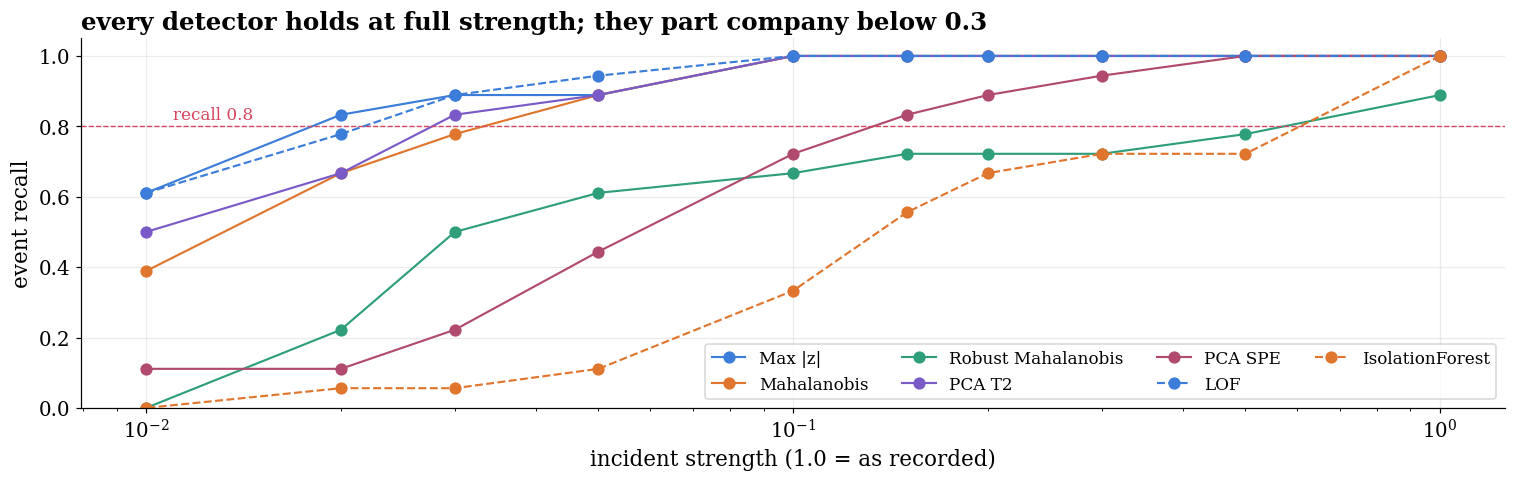

In [8]:
fig, ax = plt.subplots(figsize=(14, 4.6))
for k, det in enumerate(DETECTORS):
    ax.plot(recall_by_strength.index, recall_by_strength[det], marker="o",
            color=PORT_C[k % len(PORT_C)],
            ls=["-", "--", ":"][k // len(PORT_C)], label=det)
ax.set(xscale="log", xlabel="incident strength (1.0 = as recorded)",
       ylabel="event recall", ylim=(0, 1.05),
       title="every detector holds at full strength; they part company below 0.3")
ax.axhline(0.8, color=C["alert"], ls="--", lw=0.9)
ax.text(0.011, 0.82, "recall 0.8", color=C["alert"], fontsize=11)
ax.legend(fontsize=11, ncol=4, loc="lower right")
plt.show()

## 5. 難度轉盤

`attenuate_events()` 把每一個事件視窗往它自己的 counterfactual 拉近。counterfactual 是同一個
port、同一個 hour of week、正常樣本的中位數，也就是這段時間如果什麼都沒發生，counter 大概會是
多少。強度 1.0 是原始檔案，0.1 表示 counter 只走了原本十分之一的距離。

混合是加在 raw counter 上，特徵再從 counter 重算，所以封包數、位元組數與每一個 ratio 之間的
代數關係都還成立。直接把 feature 調弱會產生一個算術上不存在的 port，那種資料上測出來的排名不
能用。

模型與門檻在整個掃描過程中固定，唯一變動的是事件強度，所以曲線的差異只能來自方法本身。

結果和直覺相反。IsolationForest 在強度 0.5 就掉到 0.72，最簡單的 Max |z| 撐到 0.02。
IsolationForest 用軸平行的切割來隔離樣本，在十一維裡它需要異常在某個座標上明顯偏離；事件調弱
之後每一維的偏移都變小，切割就切不出來。Max |z| 反而因為只看最極端的那一維，衰減得最慢。

PCA SPE 掉得早，是因為它衡量的是離開主子空間的距離，而這批事件多半沿著子空間內部移動。這一點
Lab04 已經說過，這裡只是把它量出來。

detector,Max |z|,Mahalanobis,Robust Mahalanobis,PCA T2,PCA SPE,LOF,IsolationForest
strength,,,,,,,
1.00,-0.111,-0.056,-0.056,-0.056,-0.111,-0.111,-0.111
0.30,-0.222,-0.167,0.000,-0.222,-0.111,0.000,-0.278
0.10,-0.222,-0.278,0.000,-0.333,-0.166,-0.056,-0.055
0.05,-0.111,-0.167,-0.111,-0.278,0.056,-0.111,-0.055
0.03,-0.111,-0.111,-0.111,-0.222,0.111,-0.167,0.000


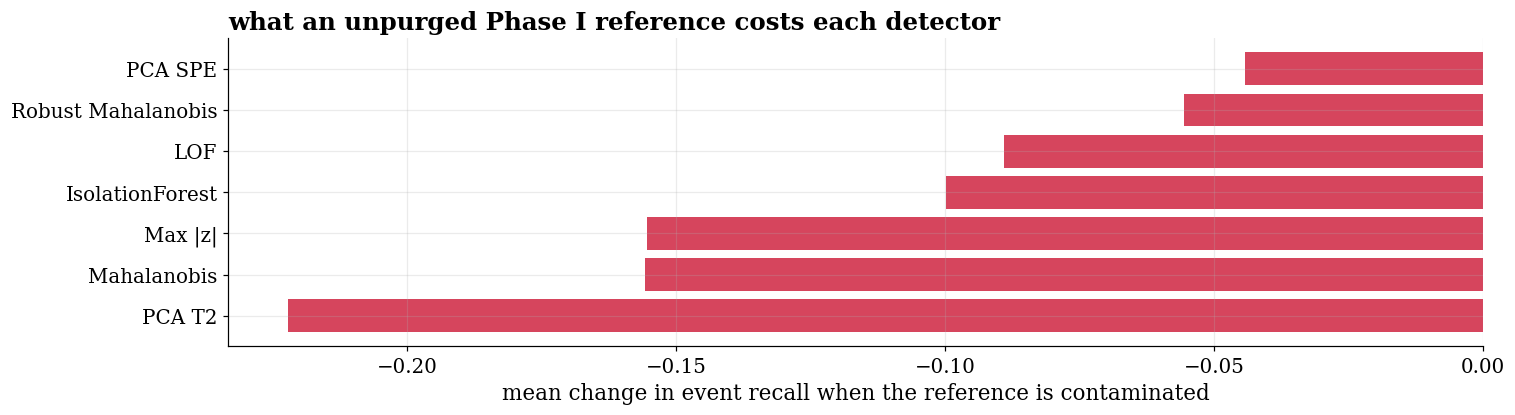

In [9]:
dirty_fit = (frame["timestamp"] < FIT_END).to_numpy()     # 事件與變更都留在參考期裡
dirty_models = fit_fleet(frame, dirty_fit)
dirty_thresholds = ev.calibrate_fleet(frame, score_fleet(frame, dirty_models), cal_mask,
                                      TARGET_ONSETS_PER_DAY, cadence_s=CADENCE_S)
dirty_recall = sweep(dirty_models, dirty_thresholds, strengths=(1.0, 0.3, 0.1, 0.05, 0.03))
lost = (dirty_recall - recall_by_strength.loc[dirty_recall.index]).round(3)
display(lost)

fig, ax = plt.subplots(figsize=(14, 4.0))
order = lost.mean().sort_values().index
ax.barh(range(len(order)), lost[order].mean(),
        color=[C["peer"] if v >= -0.02 else C["alert"] for v in lost[order].mean()])
ax.set_yticks(range(len(order)), list(order))
ax.set(xlabel="mean change in event recall when the reference is contaminated",
       title="what an unpurged Phase I reference costs each detector")
plt.show()

## 6. Reference 被污染的時候

上一格把事件留在參考期裡，其餘完全不動。這是真實環境的常態，因為沒有人有一份完整的事件紀錄。

要看的是 Mahalanobis 那一對。兩者的差別只有共變異數的估計法，其餘完全相同，所以它們之間的差
可以歸給估計法。強度 0.3 與 0.1 上，Robust Mahalanobis 掉了 0.000，一般 Mahalanobis 掉了 0.167
與 0.278。MinCovDet 只用一部分樣本估共變異數，被污染的那幾筆落在支撐集外面，模型就沒有把事件
學成正常。

跨欄比平均值在這裡會誤導。PCA SPE 的平均損失比 Robust Mahalanobis 還小，理由是它在乾淨參考期下
本來就已經很差，能掉的空間有限。污染的代價要在同一個家族內部比，否則量到的是起點而不是韌性。

保險的定價在第 5 節那張表上。參考期乾淨的時候，Robust Mahalanobis 在強度 1.0 只有 0.889，比一般
Mahalanobis 差了 0.111，因為它主動丟掉了一成資料。參考期可信就不要買，事件紀錄不完整就值得買。
Lab04 的結論把 robust covariance 列為未完成的問題，這一格是那個問題的答案。

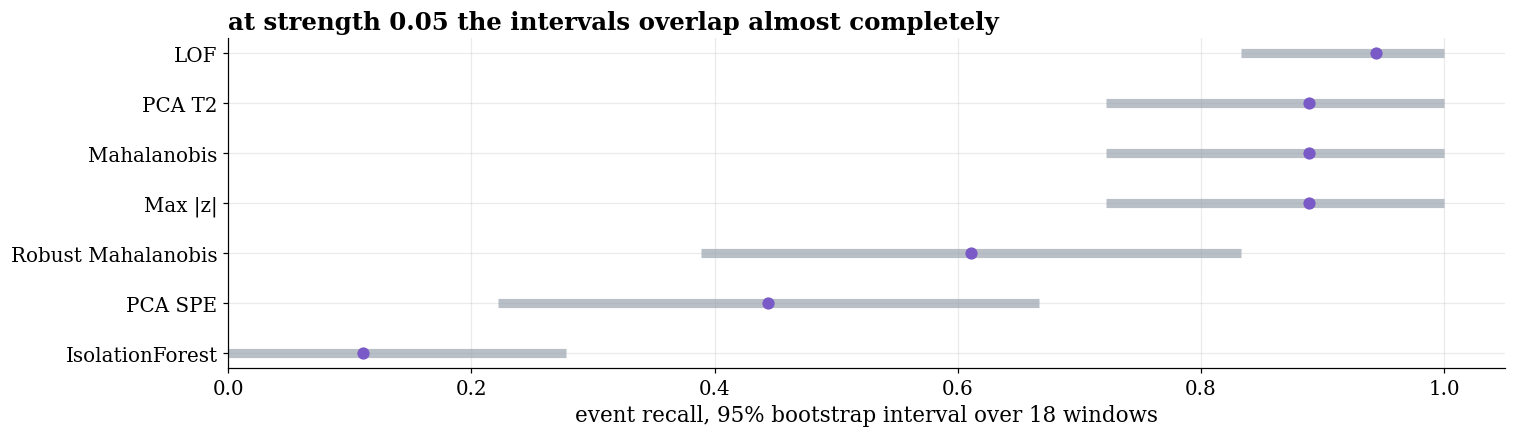

,detector,event_recall,ci95_low,ci95_high
0,IsolationForest,0.111,0.000,0.278
1,PCA SPE,0.444,0.222,0.667
2,Robust Mahalanobis,0.611,0.389,0.833
3,Max |z|,0.889,0.722,1.000
4,Mahalanobis,0.889,0.722,1.000
5,PCA T2,0.889,0.722,1.000
6,LOF,0.944,0.833,1.000


In [10]:
rows = []
for det in DETECTORS:
    outcomes = ev.window_outcomes(frame, flags[det], windows)
    boot = ev.bootstrap_windows(outcomes)
    rows.append({"detector": det, "event_recall": boot["recall"],
                 "ci95_low": boot["ci95"][0], "ci95_high": boot["ci95"][1]})
ci = pd.DataFrame(rows)

weak = engineer_features(attenuate_events(telemetry, counterfactual, 0.05))
weak_flags = ev.flag_fleet(weak, score_fleet(weak, models), thresholds)
rows = []
for det in DETECTORS:
    boot = ev.bootstrap_windows(ev.window_outcomes(weak, weak_flags[det], windows))
    rows.append({"detector": det, "event_recall": boot["recall"],
                 "ci95_low": boot["ci95"][0], "ci95_high": boot["ci95"][1]})
ci_weak = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(14, 4.2))
y = np.arange(len(ci_weak))
ci_weak = ci_weak.sort_values("event_recall").reset_index(drop=True)
ax.hlines(y, ci_weak["ci95_low"], ci_weak["ci95_high"], color=C["muted"], lw=6, alpha=0.7)
ax.plot(ci_weak["event_recall"], y, "o", color=C["score"], zorder=5)
ax.set_yticks(y, ci_weak["detector"])
ax.set(xlim=(0, 1.05), xlabel="event recall, 95% bootstrap interval over 18 windows",
       title="at strength 0.05 the intervals overlap almost completely")
plt.show()
display(ci_weak.round(3))

In [11]:
labels = is_event
print("block permutation test, detector scores against the incident labels")
for det in ("Max |z|", "IsolationForest"):
    got = ev.block_permutation_test(scores[det].to_numpy(), labels, block=288, n_perm=500)
    print(f"  {det:18s} {got}")

print("\nbreach independence, per port, Mahalanobis flags")
for pid, group in frame.groupby("port_id"):
    got = ev.breach_independence(flags.loc[group.index, "Mahalanobis"])
    print(f"  {pid[-4:]}  rate {got['breach_rate']:.5f}  adjacent {got['observed_adjacent']:4d}  "
          f"expected {got['expected_if_independent']:5.1f}  ratio {got['ratio']}")

block permutation test, detector scores against the incident labels
  Max |z|            {'observed_gap': 1981.811, 'null_mean_gap': 53.517, 'p_value': 0.002}
  IsolationForest    {'observed_gap': 0.258, 'null_mean_gap': 0.005, 'p_value': 0.002}

breach independence, per port, Mahalanobis flags
  7427  rate 0.00856  adjacent   58  expected   0.6  ratio 91.5
  7428  rate 0.00671  adjacent   46  expected   0.4  ratio 118.2
  7429  rate 0.00775  adjacent   35  expected   0.5  ratio 67.4
  7430  rate 0.01493  adjacent   70  expected   1.9  ratio 36.3
  7431  rate 0.01157  adjacent   64  expected   1.2  ratio 55.3


## 7. 這張成績單能撐起多重的結論

證據的單位是事件，不是樣本。整份資料只有十八個 window，所以 recall 的 bootstrap 是對 window
重抽，得到的區間很寬，而那個寬度就是結論本身。在強度 0.05 上，排名前後的幾個 detector 區間幾乎
完全重疊，把它們排成名次是在排雜訊。

block permutation test 用整段位移取代逐點洗牌。逐點洗牌會把讓平滑分數看起來有資訊的連續段打散，
於是 p 值小得離譜。既然第 2 節的 Ljung-Box 已經說這個序列有很強的記憶，null 就必須保留那個記憶。

獨立性的探針給出最直接的數字。相鄰兩個樣本同時越線的次數，是把它們當成獨立事件時預期值的幾十倍。
任何「每個樣本越線機率乘上樣本數等於每天幾則 alert」的估算，都會錯這麼多倍。

In [12]:
weak_scores = score_fleet(weak, models)
optimism = ev.threshold_optimism(weak, weak_scores[list(DETECTORS)], windows,
                                 cal_mask, test_mask, TARGET_ONSETS_PER_DAY,
                                 cadence_s=CADENCE_S)
display(optimism.round(3))

,detector,recall_held_out,false_held_out,recall_tuned_on_test,false_tuned_on_test,recall_optimism
0,Max |z|,0.917,0.83,0.917,0.00,0.000
1,Mahalanobis,0.917,1.00,0.917,0.00,0.000
2,PCA T2,0.917,0.92,0.917,0.00,0.000
3,LOF,1.000,0.98,1.000,0.03,0.000
4,Robust Mahalanobis,0.750,1.13,0.667,0.12,-0.083
5,IsolationForest,0.083,0.67,0.000,0.00,-0.083
6,PCA SPE,0.417,1.32,0.333,0.18,-0.084


In [13]:
early = (frame["timestamp"] < FIT_END).to_numpy() & ~is_event & ~planned
late = (frame["timestamp"] >= CAL_END).to_numpy() & ~is_event & ~planned
drift = ev.drift_ks(frame, FEATURES, early, late)
display(drift.head(6).round(4))

shifted = telemetry.copy()
shifted[RAW_COLUMNS] = shifted[RAW_COLUMNS].astype(float)
bump = (shifted["timestamp"] >= CAL_END).to_numpy()
shifted.loc[bump, ["INOCTETS", "OUTOCTETS"]] *= 1.25
drift_injected = ev.drift_ks(engineer_features(shifted), FEATURES, early, late)
display(drift_injected.head(4).round(4))

,feature,ks_stat,p_value,median_early,median_late
0,in_pps,0.015,0.0346,34.6867,33.9017
1,in_bps,0.011,0.2470,250392.2965,244415.3355
2,out_bps,0.011,0.2283,195954.3179,191769.3432
3,out_pps,0.010,0.3411,27.9467,27.2683
4,broadcast_ratio,0.009,0.3904,0.0030,0.0030
5,multicast_ratio,0.009,0.4547,0.0049,0.0049


,feature,ks_stat,p_value,median_early,median_late
0,avg_pkt_bytes,0.442,0.0000,893.2371,1115.3411
1,in_bps,0.081,0.0000,250392.2965,305519.1693
2,out_bps,0.080,0.0000,195954.3179,239711.6790
3,in_pps,0.015,0.0346,34.6867,33.9017


## 8. 門檻的樂觀，以及沒有發生的 drift

`threshold_optimism` 把同一個 detector 評分兩次。誠實的那一臂在沒有事件的 calibrate 段訂門檻，
這是實際上線那天手上有的東西。洩漏的那一臂拿到 test 段的答案，在相同的 false-onset 額度裡挑出
抓得最多的門檻。

`recall_optimism` 這一欄是 0.000，這是一個空結果，而它落在 recall 這一欄不代表沒有洩漏。看
false onset：Max |z| 從每個 port 每天 0.83 掉到 0.00，Mahalanobis 從 1.00 掉到 0.00，recall 完全
沒有變。看過答案換來的不是抓到更多事件，是用少得多的誤報抓到同樣多的事件。

會這樣是因為額度綁住了兩臂。額度以外的自由度只剩下門檻要訂多高，而 test 段的事件強到門檻可以
一路往上推。換一個沒有額度限制的目標函數，例如直接最大化 F1，洩漏就會回到 recall 欄上。報告
一個調過的數字而不附上它誠實的雙胞胎，讀者無法分辨這兩種情形。

drift 的結果是沒有 drift。十一個 feature 的 KS 統計量都在 0.02 以下，模擬器本來就是定常的，所以
這是預期中的答案。空的發現要說出來，否則讀者無法分辨探針沒找到與探針沒有作用。

第二格把後半段的 octet 乘上 1.25 之後再測一次，KS 統計量立刻跳起來。這證明的是儀器有效，不是
資料有問題。真實系統會 drift，屆時要靠這支探針分辨模型過期與現場出事，而它必須先被驗證過。

## 9. 根因的四把尺

到這裡為止量的都是偵測。工程師拿到 alert 之後要回答的問題不在這些數字裡，所以這一節定義四個
互相獨立的量，全部可以從事件表與變更行事曆算出來。

| 量 | 問題 | 真值來源 |
| --- | --- | --- |
| attribution hit@k | 解釋有沒有指到真正在動的 counter | `FAULT_SIGNATURE`，由事件描述寫成 |
| localization | 影響範圍的 port 有沒有指對，而且沒有多指 | telemetry 上的 `event_id` 與 `port_id` |
| cause typing | 事件的種類有沒有叫對 | `event_type` |
| suppression | 已公告的變更有沒有安靜下來 | `change_calendar.csv` |

四個分開量，因為一個方法可以贏一項輸另一項。peer context 會大幅改善 localization，對 attribution
完全沒有影響；變更行事曆改善 suppression，代價是 recall。合成一個「RCA 分數」會把這些取捨蓋掉。

`FAULT_SIGNATURE` 從事件描述寫成，不是從資料擬合出來的。方向很重要：用同一份資料推出來的真值表
去評分歸因，量到的是自己的假設。表和資料不一致的時候，那是關於其中一方的發現，不是回頭改表的理由。

In [14]:
DETECTOR = "Mahalanobis"          # 歸因要靠得住的模型，第 5 節顯示它在污染下才是弱點
table = rca.attribution_table(models, frame, scores, windows, DETECTOR)
display(table[["event_id", "event_type", "port",
               "R0 max |z| top1", "R1 PCA SPE share top1",
               "R2 leave-one-out top1", "R3 counterfactual top1"]])
summary = rca.attribution_summary(table)
display(summary)
chance1, chance3 = rca.random_baseline(k=1), rca.random_baseline(k=3)
print(f"a uniformly random pick would score hit@1 {chance1} and hit@3 {chance3}")

,event_id,event_type,port,R0 max |z| top1,R1 PCA SPE share top1,R2 leave-one-out top1,R3 counterfactual top1
0,A,business_traffic_growth,7430,multicast_ratio,error_rate,multicast_ratio,in_pps
1,B,small_packet_scan,7428,in_pps,avg_pkt_bytes,broadcast_ratio,in_pps
2,C,large_file_backup,7431,multicast_ratio,avg_pkt_bytes,multicast_ratio,multicast_ratio
3,D,queue_congestion,7427,broadcast_ratio,error_rate,discard_rate,discard_rate
4,E,link_quality_issue,7429,error_rate,error_rate,error_rate,error_rate
5,F,load_sensitive_link_issue,7427,error_rate,error_rate,error_rate,error_rate
6,G,broadcast_storm,7427,broadcast_ratio,error_rate,broadcast_ratio,broadcast_ratio
7,G,broadcast_storm,7428,broadcast_ratio,error_rate,broadcast_ratio,broadcast_ratio
8,G,broadcast_storm,7429,broadcast_ratio,error_rate,broadcast_ratio,broadcast_ratio
9,G,broadcast_storm,7430,broadcast_ratio,avg_pkt_bytes,broadcast_ratio,broadcast_ratio


,attribution,hit@1,hit@3
0,R3 counterfactual,0.944,1.000
1,R0 max |z|,0.833,1.000
2,R2 leave-one-out,0.778,0.833
3,R1 PCA SPE share,0.278,0.389


a uniformly random pick would score hit@1 0.209 and hit@3 0.518


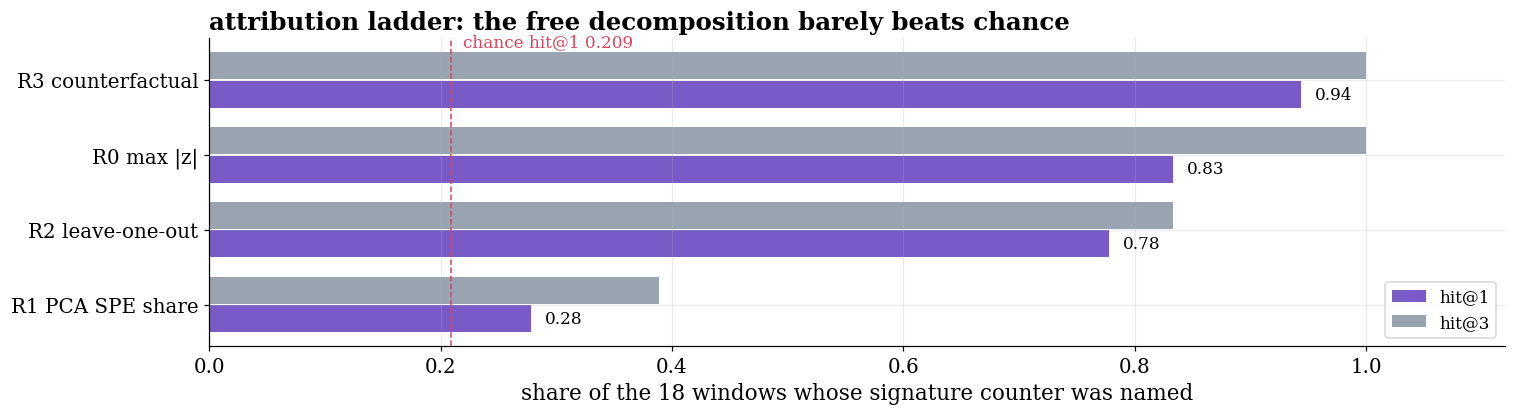

In [15]:
fig, ax = plt.subplots(figsize=(14, 4.0))
order = summary.sort_values("hit@1")
y = np.arange(len(order))
ax.barh(y - 0.19, order["hit@1"], height=0.36, color=C["score"], label="hit@1")
ax.barh(y + 0.19, order["hit@3"], height=0.36, color=C["muted"], label="hit@3")
for n, row in enumerate(order.itertuples()):
    ax.text(row._2 + 0.012, n - 0.19, f"{row._2:.2f}", va="center", fontsize=11)
ax.axvline(chance1, color=C["alert"], ls="--", lw=1.0)
ax.text(chance1 + 0.01, len(order) - 0.55, f"chance hit@1 {chance1}",
        color=C["alert"], fontsize=11)
ax.set_yticks(y, order["attribution"])
ax.set(xlim=(0, 1.12), xlabel="share of the 18 windows whose signature counter was named",
       title="attribution ladder: the free decomposition barely beats chance")
ax.legend(fontsize=11, loc="lower right")
plt.show()

## 10. 歸因的四個階梯

R1 是 PCA 重建誤差的逐欄拆解。它免費，因為可加的分數會自己拆開，而它是四個裡面最差的一個，
hit@1 只有 0.28。原因是平方誤差被殘差尾巴最重的那一欄吃掉，於是不管發生什麼事，`error_rate`
都排第一。免費的拆解在數學上正確，在歸因上沒有用。

R0 直接看標準化之後最極端的那一維，0.83。它錯的三次全部是同一個機制：`broadcast_ratio` 與
`multicast_ratio` 的分母是封包總數，流量一漲，分子沒動，比值也會被推出正常帶。第 2 節那三個
ratio 的正常帶本來就很窄，一點分母變化就是幾十個 sigma。

R2 把一個 feature 拉回正常再重算分數，用掉的分數當作它的貢獻，0.78。它輸給 R0 的地方在相關的
feature 上：`in_bps` 與 `out_bps` 一起動的時候，單獨拉回其中一個，另一個還撐著分數，於是兩個
看起來都不重要。

R3 反過來問，如果只有這一個 feature 偏離、其他全部正常，分數還剩多少。相關的兩欄各自都還很高，
所以不會互相抵銷，hit@1 到 0.94。它修好了 R0 在 business traffic growth 與 queue congestion 上
的比值假象，剩下一次沒修好的是 large file backup，第 12 節會說明那一次為什麼是真的。

,event_id,event_type,catalog_scope,ports_true,ports_fired,missed,spurious,jaccard,common_mode_called,common_mode_true
0,A,business_traffic_growth,port-id7430,1,1,0,0,1.000,False,False
1,B,small_packet_scan,port-id7428,1,1,0,0,1.000,False,False
2,C,large_file_backup,port-id7431,1,3,0,2,0.333,True,False
3,D,queue_congestion,port-id7427,1,1,0,0,1.000,False,False
4,E,link_quality_issue,port-id7429,1,1,0,0,1.000,False,False
5,F,load_sensitive_link_issue,port-id7427,1,1,0,0,1.000,False,False
6,G,broadcast_storm,MULTI,5,5,0,0,1.000,True,True
7,H,multicast_flooding,MULTI,5,5,0,0,1.000,True,True
8,I,abnormal_device_sender,port-id7430,1,2,0,1,0.500,False,False
9,J,unknown_protocol_scan,port-id7428,1,1,0,0,1.000,False,False


mean jaccard 0.883   common-mode accuracy 0.9


,attribution,type_accuracy
0,R0 max |z|,0.889
1,R3 counterfactual,0.889
2,R2 leave-one-out,0.722
3,R1 PCA SPE share,0.167


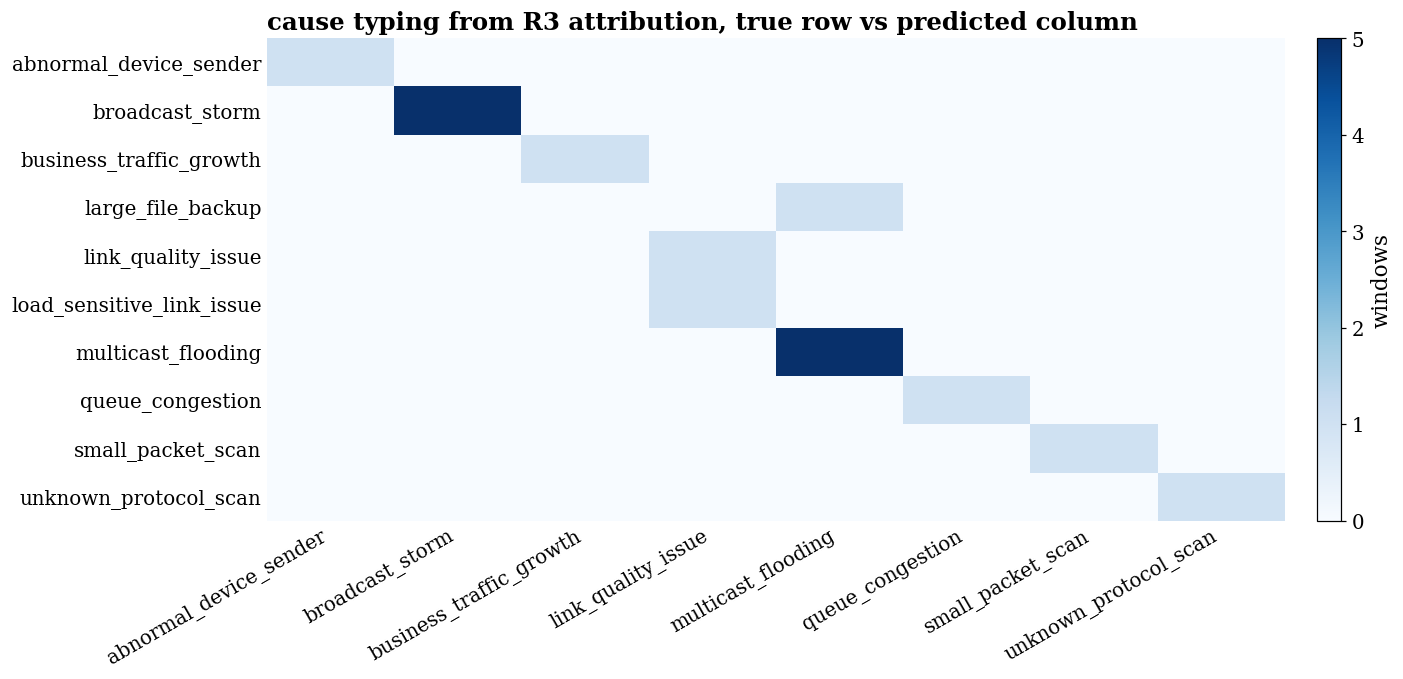

<Axes: title={'left': 'cause typing from R3 attribution, true row vs predicted column'}>

In [16]:
local = rca.localization(frame, flags[DETECTOR], windows, catalog)
display(local)
print(f"mean jaccard {local.attrs['mean_jaccard']}   "
      f"common-mode accuracy {local.attrs['common_mode_accuracy']}")

rows = []
for method in rca.ATTRIBUTIONS:
    typing = rca.cause_typing(models, frame, scores, windows, DETECTOR, method=method)
    rows.append({"attribution": method,
                 "type_accuracy": round(float(typing["correct"].mean()), 3)})
typing_summary = pd.DataFrame(rows).sort_values("type_accuracy", ascending=False)
display(typing_summary.reset_index(drop=True))

typing = rca.cause_typing(models, frame, scores, windows, DETECTOR)
heatmap(rca.confusion(typing), title="cause typing from R3 attribution, true row vs predicted column",
        fmt="{:.0f}", cbar_label="windows")

## 11. 影響範圍與事件種類

localization 的平均 Jaccard 是 0.883，common-mode 的判斷十次對九次。兩個 MULTI 事件，broadcast
storm 與 multicast flooding，五個 port 全中而且沒有多報，所以「上游共通因素」這個判斷站得住。

錯的是 large file backup 與 abnormal device sender，兩者都多報了 port。備份把整台儲存設備的流量
拉高，鄰近的 port 也跟著動，偵測器沒有辦法只憑單點分數說那是同一件事的側面。peer context 在這裡
只能提供證據，不能提供答案。

cause typing 把歸因的份額對到 signature 表上。判準有兩個部分，coverage 是解釋的份額有多少落在
這個種類的 signature 上，specificity 是 signature 裡真的動了的比例。只看第一個，signature 較大
的種類會靠包含關係贏，`load_sensitive_link_issue` 含有 `link_quality_issue` 的全部欄位，純線路
故障時它的 coverage 是滿的。只看集合交集更糟，兩個單欄 signature 會平手，然後由排序決定，於是
broadcast storm 會被叫成 multicast flooding。

R3 與 R0 都是 0.889，R2 掉到 0.722，R1 只有 0.167。這裡 R0 追平 R3，而 attribution hit@1 上
R3 領先 0.11。同一組方法在兩把尺上排出不同的名次，這正是四把尺分開量的理由。

兩次錯誤都是真的。large file backup 被叫成 multicast flooding，因為備份期間封包數掉到三成，
multicast 的絕對量沒變，比值就衝上去，而 signature 表寫的是 `avg_pkt_bytes`。表與資料在這裡
不一致，該記錄下來的是這個不一致，不是把表改成資料的樣子。load sensitive link issue 被叫成
link quality issue，因為前者的 signature 包含後者，而歸因只指到 `error_rate`。這兩種故障在現場
的差別是當時流量高不高，光看單一樣本的偏離量分不出來。

In [17]:
suppressed = rca.suppression(frame, flags[DETECTOR], windows, planned, catalog, calendar)
display(suppressed)
print("announced incidents:", suppressed.attrs["announced_events"])
display(calendar[["change_id", "change_type", "scope", "start_time", "end_time", "description"]])

,arm,real_faults_caught,announced_still_alerting,announced_windows,alert_samples
0,no calendar,16/16,2,2,428
1,calendar applied,16/16,0,2,367


announced incidents: ['A', 'C']


,change_id,change_type,scope,start_time,end_time,description
0,CH-01,scheduled_backup,port-id7431,2026-02-08 00:50:00,2026-02-08 04:10:00,週日夜間全量備份至異地儲存
1,CH-02,business_change,port-id7430,2026-02-04 08:50:00,2026-02-04 11:05:00,新業務系統上線導流至 office VLAN
2,CH-03,maintenance,core-sw-01,2026-02-16 02:00:00,2026-02-16 04:00:00,核心交換器韌體升級維護視窗
3,CH-04,maintenance,edge-fw-01,2026-02-21 03:00:00,2026-02-21 05:00:00,邊界防火牆規則批次更新


## 12. 已公告的變更

事件 A 與事件 C 各自落在 CH-02 與 CH-01 底下，一個是新業務上線導流，一個是週日夜間全量備份。
在線路上它們和故障沒有分別，能分辨的只有那份行事曆。

套上行事曆之後，兩個公告過的事件不再發出 alert，十六個真故障一個都沒有少，alert 樣本從 428 降到
367。這是理想的結果，而要看的數字不是省下多少噪音，是有沒有把真故障一起消音。那種失誤不會有人
發現，它會以一次沒有人被叫醒的故障出現。

CH-03 與 CH-04 的 scope 寫的是 device 而不是 port，所以一筆變更覆蓋那台設備上的每一個 port。
`calendar_mask()` 把兩種 scope 都解析，寫死成 port 比對會讓核心交換器的維護視窗完全失效。

In [18]:
packet = rca.build_incident_context(frame, scores, thresholds, models, windows, catalog,
                                    calendar, planned, "G", "port-id7429", DETECTOR)
print(json.dumps(packet, ensure_ascii=False, indent=2))

{
  "device_id": "core-sw-01",
  "port_id": "port-id7429",
  "port_role": "server-uplink",
  "window_start": "2026-02-19 11:30:00",
  "duration_min": 60,
  "detector": "Mahalanobis",
  "score": 1465.7,
  "threshold": 11.0,
  "score_over_threshold": 133.1,
  "attribution_method": "R3 counterfactual",
  "attribution_top3": {
    "broadcast_ratio": 0.913,
    "discard_rate": 0.047,
    "multicast_ratio": 0.029
  },
  "measured_at_peak": {
    "broadcast_ratio": 0.0387,
    "discard_rate": 0.0015,
    "multicast_ratio": 0.0038
  },
  "normal_median": {
    "broadcast_ratio": 0.0028,
    "discard_rate": 0.0,
    "multicast_ratio": 0.0049
  },
  "peer_ports_deviating": 4,
  "peer_ports_total": 4,
  "planned_change": "",
  "planned_change_description": "",
  "candidate_type_from_signature": "broadcast_storm",
  "ground_truth_type": "broadcast_storm"
}


In [19]:
call_tool, recorded = rca.make_tools(frame, scores, thresholds, calendar, DETECTOR)
report, calls = rca.run_rca_agent(packet, call_tool)
print(report)
print(f"\ntools called: {[c['tool'] for c in calls]}")
print(f"recorded summaries pending approval: {recorded}")
display(pd.Series(rca.score_rca_report(report, packet)).to_frame("value"))

Cause: common-mode event upstream of every port, 4 of 4 peers deviating, leading counter [broadcast_ratio]. Confidence high, from [attribution_top3] and [peer_ports_deviating].
Runner-up: a load-driven side effect of an unannounced change, not separated by [planned_change].
Evidence: score 1465.7 against threshold 11.0, 133.1x, from [score] and [threshold]. Signature match suggests broadcast_storm, from [candidate_type_from_signature].
To separate them: confirm whether [broadcast_ratio] moved on the peer ports at the same minute, and whether a change ticket exists that was never filed.
Severity critical; escalation requested, pending human approval.

tools called: ['get_recent_metrics', 'check_related_devices', 'check_change_calendar', 'create_incident_summary']
recorded summaries pending approval: [{'severity': 'critical', 'root_causes': ['common-mode event upstream of every port, 4 of 4 peers deviating, leading counter [broadcast_ratio]', 'a load-driven side effect of an unannounced 

,value
sentences,7
sentences_citing_a_field,6
citation_rate,0.86
distinct_fields_cited,6
predicted_type,broadcast_storm
true_type,broadcast_storm
type_correct,True


In [20]:
rows = []
for event_id, port_id in (("G", "port-id7429"), ("H", "port-id7427"),
                          ("C", "port-id7431"), ("J", "port-id7428"),
                          ("D", "port-id7427"), ("I", "port-id7430")):
    pkt = rca.build_incident_context(frame, scores, thresholds, models, windows, catalog,
                                     calendar, planned, event_id, port_id, DETECTOR)
    text, _ = rca.run_rca_agent(pkt, call_tool)
    rows.append({"event_id": event_id, **rca.score_rca_report(text, pkt)})
display(pd.DataFrame(rows))

print("--- grounded prompt, first 12 lines ---")
print("\n".join(rca.grounded_prompt(packet).splitlines()[:12]))
print("\n--- loose prompt, first 3 lines ---")
print("\n".join(rca.loose_prompt(packet).splitlines()[:3]))

,event_id,sentences,sentences_citing_a_field,citation_rate,distinct_fields_cited,predicted_type,true_type,type_correct
0,G,7,6,0.86,6,broadcast_storm,broadcast_storm,True
1,H,7,6,0.86,6,multicast_flooding,multicast_flooding,True
2,C,7,6,0.86,6,multicast_flooding,large_file_backup,False
3,J,7,6,0.86,6,unknown_protocol_scan,unknown_protocol_scan,True
4,D,7,6,0.86,6,queue_congestion,queue_congestion,True
5,I,7,6,0.86,6,abnormal_device_sender,abnormal_device_sender,True


--- grounded prompt, first 12 lines ---
You are a network incident investigator. Evidence is supplied by monitoring tools. Use only the values in the packet and the tool results. Never invent a number. Cite the packet field behind every claim. Rank causes, give the runner-up, and state what further evidence would separate them. If the packet cannot distinguish a real fault from an announced change, say so. No action executes without human approval.

Rules:
1. Use only the numbers in the packet.
2. Every claim cites its field, for example [attribution_top3].
3. One most-supported cause, one runner-up, the evidence for each.
4. Say which further measurement would separate them.
5. Give confidence as low, medium or high, and answer in at most five sentences.

EVIDENCE PACKET:
{
  "device_id": "core-sw-01",

--- loose prompt, first 3 lines ---
You are a network expert. Explain the root cause of this incident:
{
  "device_id": "core-sw-01",


## 13. 交給模型之前，先把證據算完

evidence packet 裡的每一個欄位都是工具算出來的。模型下游的工作是排序與陳述 packet 已經有的東西，
不是從它看不到的 raw telemetry 推導原因。`ground_truth_type` 不會跨過這條界線，`_redacted()`
在組 prompt 的時候就把它拿掉，否則評分是在評模型會不會抄答案。

課程沒有 API key，也需要在每一台機器上得到一樣的輸出，所以 `run_rca_agent()` 是一張決策表而不是
一個模型。它保留的是值得教的那個結構：工具清單先宣告，agent 只能呼叫清單裡的東西，證據透過工具
呼叫進來，寫出來的摘要標成等待人工核可。把 `make_tools()` 指向真的 Prometheus，就是這份 notebook
搬進 production 的全部工作。

兩個 prompt 的差別可以評分。grounded 那一份要求每一句話標出它依據的欄位，於是 citation rate 可以
量，而讀者可以逐句回去查。loose 那一份沒有這個要求，它會產生同樣流暢、但沒有一句能查證的文字。
流暢是不能用的報告最常具備的特質。

上一格對六個事件跑同一套流程。`type_correct` 在 large file backup 上是 False，理由第 11 節說過。
模型沒有把它救回來，也不應該救：packet 給的歸因就是 `multicast_ratio`，模型如果自己改成別的答案，
那是幻覺剛好猜對，下一次就會猜錯。

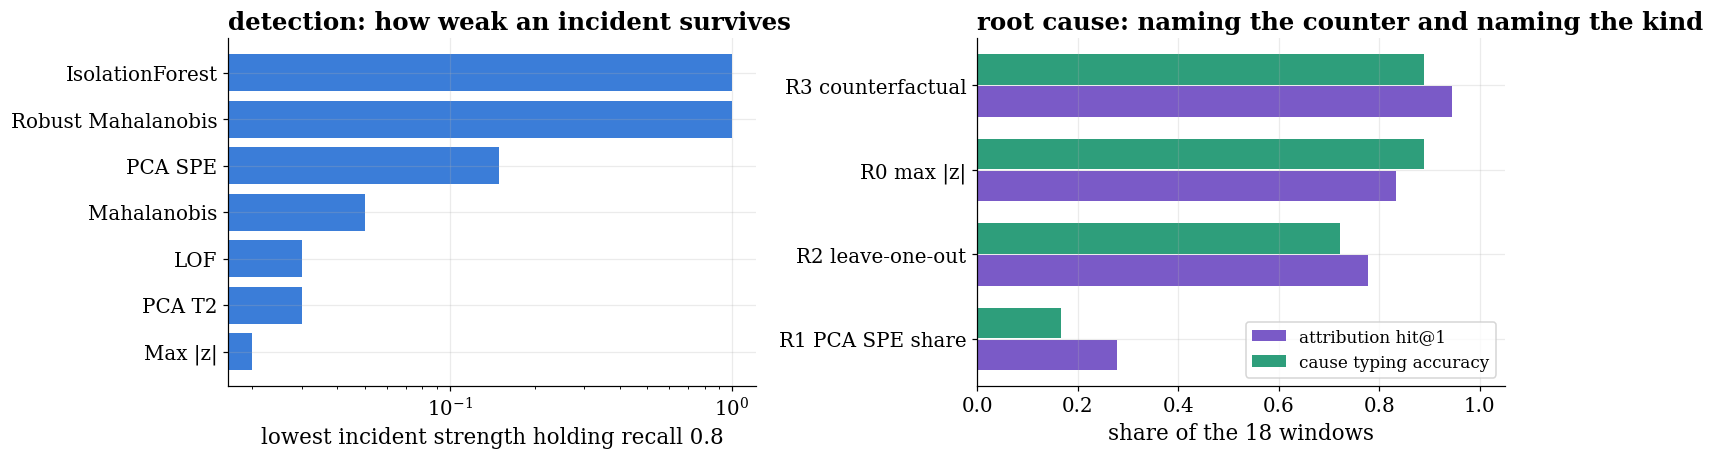

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))

f_order = floors.dropna().sort_values()
axes[0].barh(range(len(f_order)), f_order.to_numpy(), color=C["signal"])
axes[0].set_yticks(range(len(f_order)), list(f_order.index))
axes[0].set(xscale="log", xlabel="lowest incident strength holding recall 0.8",
            title="detection: how weak an incident survives")

merged = summary.merge(typing_summary, on="attribution").sort_values("hit@1")
y = np.arange(len(merged))
axes[1].barh(y - 0.19, merged["hit@1"], height=0.36, color=C["score"],
             label="attribution hit@1")
axes[1].barh(y + 0.19, merged["type_accuracy"], height=0.36, color=C["peer"],
             label="cause typing accuracy")
axes[1].set_yticks(y, merged["attribution"])
axes[1].set(xlim=(0, 1.05), xlabel="share of the 18 windows",
            title="root cause: naming the counter and naming the kind")
axes[1].legend(fontsize=11, loc="lower right")
plt.show()

## 14. 結論

**偵測是簡單的那一半。** 原始強度下七個 detector 有六個滿分，把事件調弱才排得出名次，而排出來的
名次和直覺相反：最簡單的 Max |z| 撐到強度 0.02，IsolationForest 在 0.5 就開始掉。方法的優劣是
相對於題目的形狀，不是相對於方法的複雜度。

**成績單是估計值。** 十八個 window 撐起來的 bootstrap 區間，在弱事件上幾乎完全重疊。分數序列有
很強的記憶，相鄰越線的次數是獨立假設預期值的幾十倍，所以任何逐點的顯著性檢定都會給出過小的
p 值。門檻只要看過答案就會樂觀。

**免費的解釋通常最貴。** PCA 重建誤差的逐欄拆解不用另外計算，hit@1 是 0.28。多花十一次重新評分
的 counterfactual 歸因是 0.94。歸因方法是一個選擇，而不是分數的附屬品。

**根因不是一個數字。** attribution 上 R3 領先 R0 零點一一，cause typing 上兩者平手，localization
被 peer 的行為決定而與歸因方法無關，suppression 完全由那份行事曆決定。合成一個總分會把這些取捨
全部蓋掉。

**已公告的變更要靠紀錄，不靠演算法。** A 與 C 在線路上和故障沒有分別。行事曆讓它們安靜下來而
沒有漏掉任何一個真故障，這是這一整套流程裡最便宜也最有效的一步，而它一行模型都沒有用到。

**人在最後一格。** `create_incident_summary` 回傳的是 `pending_human_approval`。這一節量到的
歸因準確率是 0.94，也就是十八次裡錯一次。以那個錯誤率自動執行動作，代價由現場承擔。

### 接下來

把 `lib/rca.py` 的 `make_tools()` 指向真的 Prometheus，evidence packet 與評分方式都不用改。
`FAULT_SIGNATURE` 換成你自己機房的工程表，第 9 到第 12 節的四把尺就會量你自己的事件。真值來自
你的事件單與變更單，這一節的所有結論都只在有那兩份紀錄的前提下成立。